In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install scipy zstandard torch matplotlib numpy --quiet

In [3]:
import os, math, struct
import numpy as np
import scipy.io
import scipy.signal
import matplotlib
import matplotlib.pyplot as plt
import zstandard as zstd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

CHECKPOINT_PATH = r'/content/drive/MyDrive/avdct_net_checkpoint.pth'
# BCI Competition III, Wads 2004 dataset folder
DATA_PATH       = r'/content/drive/MyDrive/BCI_Comp_III_Wads_2004/BCI_Comp_III_Wads_2004'

# ── Model / Data Hyper-parameters (paper Table I / Section IV-C) ────────────
NUM_CHANNELS = 64       # 64-channel EEG
L            = 64       # Block length
N_SUBBANDS   = 3        # Parallel subbands in MCDCB (Section III-A-1)
FS           = 240      # BCI3 sampling frequency (Hz)
BATCH_SIZE   = 16
LR           = 1e-4     # Fine-tuning LR (lower than BCI2 training)
NUM_EPOCHS   = 10       # Fine-tune epochs on Subject A (ATr 70%)
LAMBDA       = 1e-5     # KL weight λ  (paper Section IV-C)
SPARSITY_RHO = 0.60     # Stop-training zero-fraction threshold ρ

# ── Quantisation params for BCI3 (paper Section IV-E, Eq. 27) ──────────────
TAU          = 4
OMEGA        = 20
QUANT_SCALE  = (10 ** TAU) / OMEGA

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'τ={TAU}, ω={OMEGA} → QUANT_SCALE = {QUANT_SCALE:.2f}')


Device: cuda
τ=4, ω=20 → QUANT_SCALE = 500.00


In [4]:
# ─── BCI3 dataset structure ───────────────────────────────────────────────
# Each .mat file has key 'Signal': shape (n_trials, n_samples_per_trial, 64)
# Sampling freq: 240 Hz.  Each character record = 7560 time-points / channel
# Paper splits:  ATr → train (70%) + test-S1 (30%)
#                ATe → test-S2 (Subject A test)
#                BTr → test-S3 (Subject B train, cross-subject transfer)
#                BTe → test-S4 (Subject B test,  cross-subject transfer)

def bandpass_filter(data, lowcut=0.5, highcut=30.0, fs=FS, order=4):
    """4th-order Butterworth band-pass 0.5–30 Hz applied channel-wise."""
    nyq = 0.5 * fs
    b, a = scipy.signal.butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    out = np.zeros_like(data)
    for ch in range(data.shape[1]):
        out[:, ch] = scipy.signal.filtfilt(b, a, data[:, ch])
    return out


def extract_blocks(file_name):
    """
    Load a BCI3 .mat file, bandpass-filter and z-score the entire session,
    then segment into non-overlapping blocks of length L.

    This preserves inter-trial variability within the session/file.
    Returns: np.ndarray of shape (n_blocks, 64, L)
    """
    path = os.path.join(DATA_PATH, file_name)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    mat  = scipy.io.loadmat(path)

    if 'Signal' in mat:
        data = mat['Signal']
    else:
        key  = [k for k in mat if not k.startswith('__')][0]
        data = mat[key]

    data = data.astype(np.float64) # (n_trials, n_samples, 64)

    # 1. Bandpass filter all trials first
    all_filt = []
    for trial in data:
        all_filt.append(bandpass_filter(trial))

    # 2. Global Z-score for this entire file (session)
    concatenated = np.concatenate(all_filt, axis=0)
    mu = concatenated.mean(axis=0)
    sigma = concatenated.std(axis=0) + 1e-8

    # 3. Segment into blocks
    blocks = []
    for filt_trial in all_filt:
        norm_trial = (filt_trial - mu) / sigma
        n_blks = norm_trial.shape[0] // L
        for i in range(n_blks):
            block = norm_trial[i * L:(i + 1) * L, :]
            blocks.append(block.T)

    return np.array(blocks, dtype=np.float32)

# Global data path
DATA_PATH = r'/content/drive/MyDrive/BCI_Comp_III_Wads_2004/BCI_Comp_III_Wads_2004'

print('Loading BCI3 (Wads 2004) Subject A and Subject B data ...')
ATr_all = extract_blocks('Subject_A_Train.mat')
ATe_all = extract_blocks('Subject_A_Test.mat')
BTr_all = extract_blocks('Subject_B_Train.mat')
BTe_all = extract_blocks('Subject_B_Test.mat')
print(f'ATr={ATr_all.shape}, ATe={ATe_all.shape}, BTr={BTr_all.shape}, BTe={BTe_all.shape}')

# ── Paper splits (Section IV-E) ─────────────────────────────────────────────
split_idx  = 7246
train_data = ATr_all[:split_idx]
test_s1    = ATr_all[split_idx:]
test_s2    = ATe_all
test_s3    = BTr_all
test_s4    = BTe_all

test_sets = {
    'S1 (30% ATr)': test_s1,
    'S2 (ATe)':     test_s2,
    'S3 (BTr)':     test_s3,
    'S4 (BTe)':     test_s4,
}

print(f'\nTraining Set : {len(train_data):>6} samples')
for name, ds in test_sets.items():
    print(f'Test {name:<12}: {len(ds):>6} samples')


Loading BCI3 (Wads 2004) Subject A and Subject B data ...
ATr=(10285, 64, 64), ATe=(12100, 64, 64), BTr=(10285, 64, 64), BTe=(12100, 64, 64)

Training Set :   7246 samples
Test S1 (30% ATr):   3039 samples
Test S2 (ATe)    :  12100 samples
Test S3 (BTr)    :  10285 samples
Test S4 (BTe)    :  12100 samples


Plotting one channel for each data split...


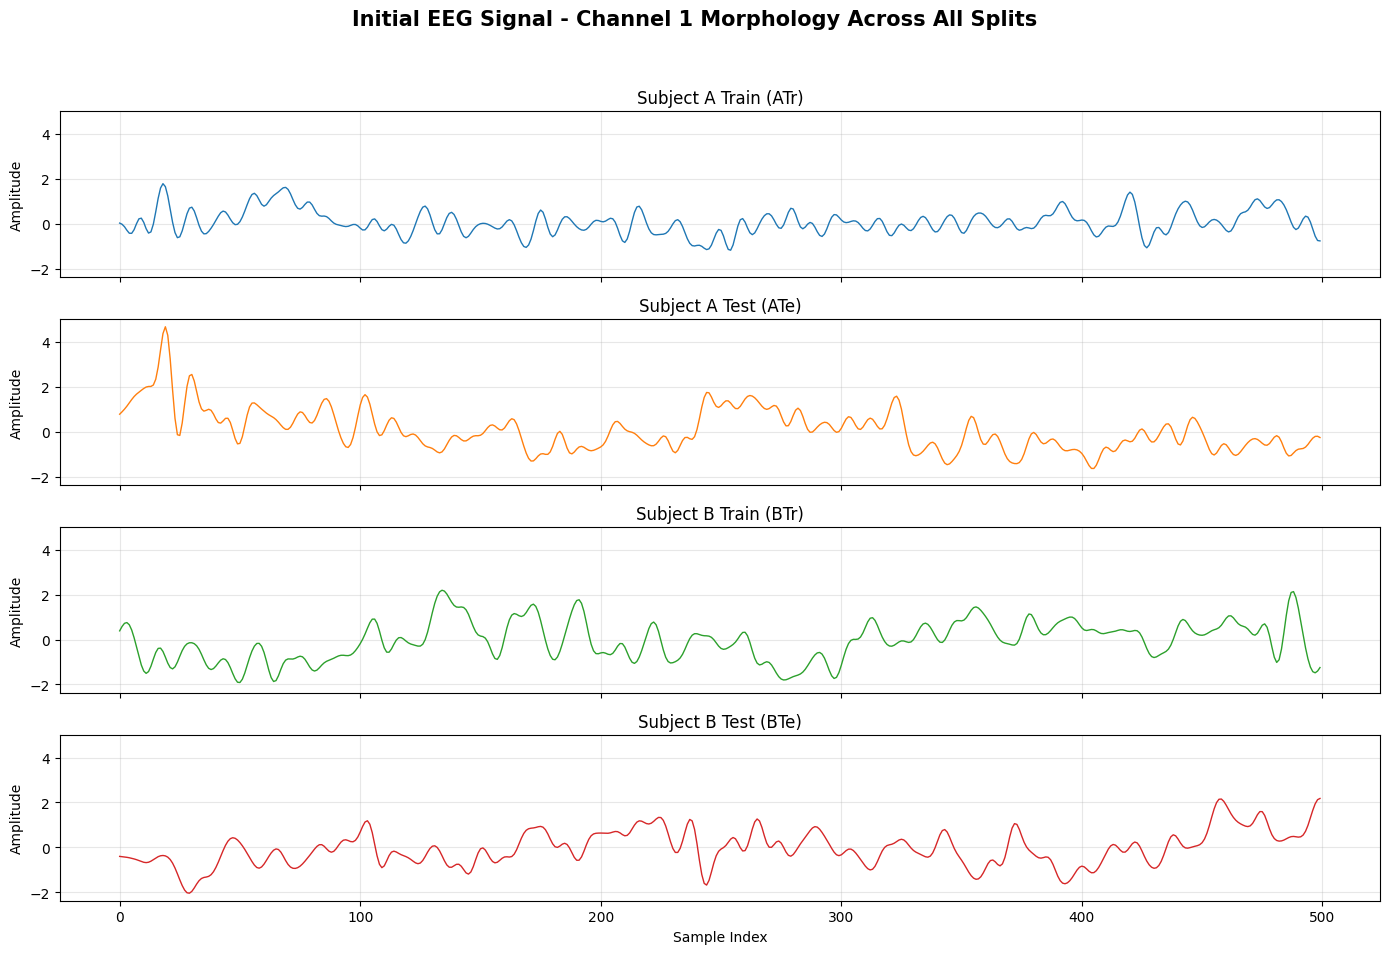

In [5]:
# ── Visualization: Initial Exploratory Data Plot (1 Channel) ──
def plot_initial_splits(atr, ate, btr, bte, channel_idx=0, n_samples=500):
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True, sharey=True)

    data_list = [
        (atr, "Subject A Train (ATr)"),
        (ate, "Subject A Test (ATe)"),
        (btr, "Subject B Train (BTr)"),
        (bte, "Subject B Test (BTe)")
    ]

    for i, (data, label) in enumerate(data_list):
        # Flatten first few blocks of the channel to get a continuous trace
        signal = data[:, channel_idx, :].reshape(-1)[:n_samples]
        axes[i].plot(signal, color=f"C{i}", linewidth=1)
        axes[i].set_title(label, fontsize=12)
        axes[i].set_ylabel("Amplitude")
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Sample Index")
    fig.suptitle(f"Initial EEG Signal - Channel {channel_idx+1} Morphology Across All Splits", fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Plotting one channel for each data split...")
plot_initial_splits(ATr_all, ATe_all, BTr_all, BTe_all, channel_idx=0)



Single Channel (Channel 1) Statistics for Verification:
-------------------------------------------------------------------------------------
Subject A Train      | Mean: 0.005979 | Std: 0.936207 | Max: 13.809439 | Min: -13.119084
Subject A Test       | Mean: 0.008241 | Std: 0.989934 | Max: 13.456753 | Min: -8.781305
Subject B Train      | Mean: 0.000996 | Std: 0.995146 | Max: 9.480134 | Min: -6.108467
Subject B Test       | Mean: 0.000758 | Std: 0.999906 | Max: 12.965651 | Min: -12.353697


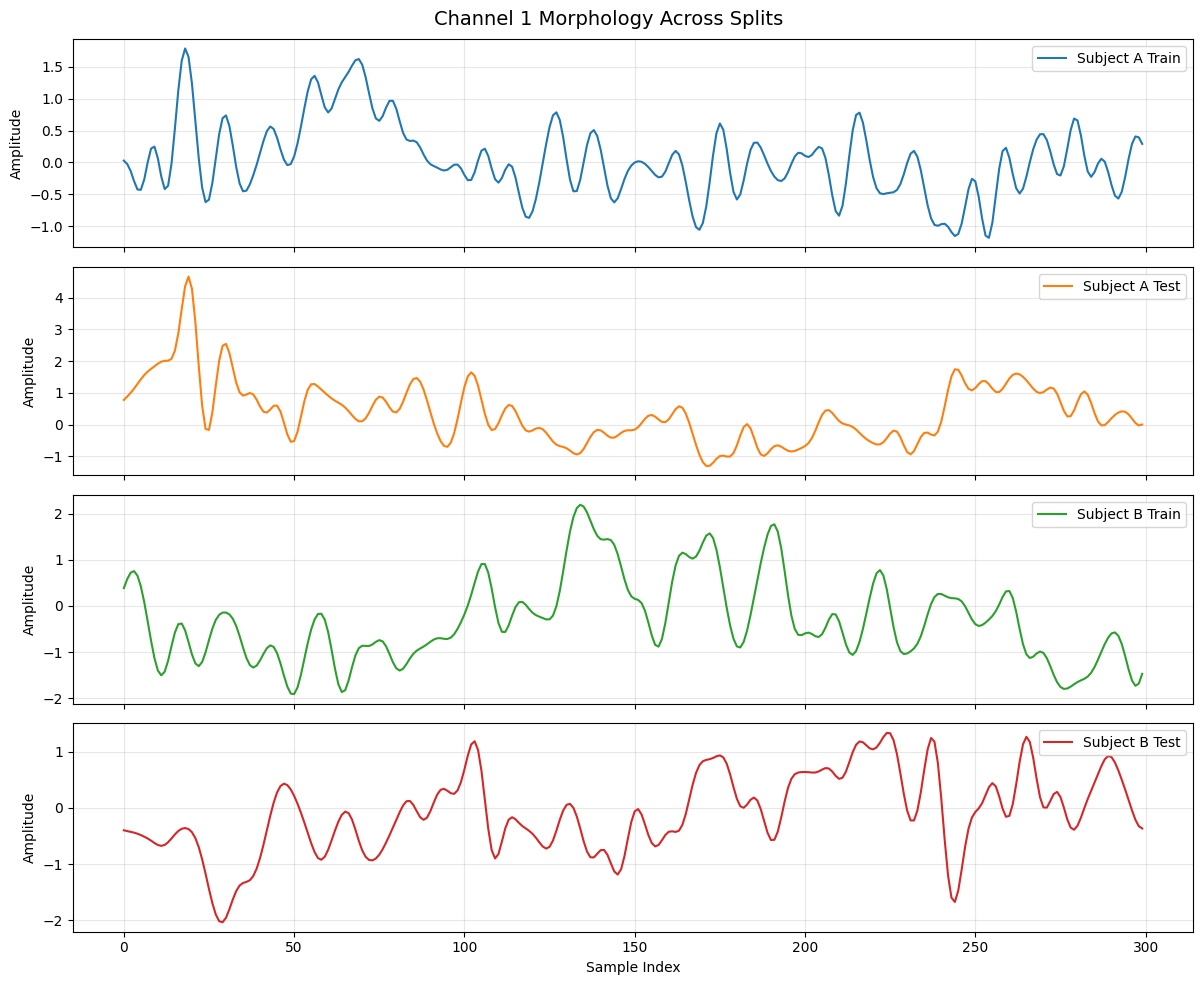

In [6]:
# ── Visualization: Inspecting Single Channel Data (Standard Alignment) ──
def print_channel_stats(data, name, channel_idx=0):
    # data shape: (n_blocks, 64, L)
    ch_data = data[:, channel_idx, :].flatten()
    print(f"{name:<20} | Mean: {ch_data.mean():.6f} | Std: {ch_data.std():.6f} | Max: {ch_data.max():.6f} | Min: {ch_data.min():.6f}")

def plot_comparison(atrain, atest, btrain, btest, channel_idx=0, n_samples=300):
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    sets = [(atrain, 'Subject A Train'), (atest, 'Subject A Test'),
            (btrain, 'Subject B Train'), (btest, 'Subject B Test')]

    print("\nSingle Channel (Channel 1) Statistics for Verification:")
    print("-" * 85)
    for i, (data, label) in enumerate(sets):
        # Extract first few samples of a channel
        # Reshape to (n_blocks * L) to get continuous signal
        signal = data[:, channel_idx, :].reshape(-1)[:n_samples]
        axes[i].plot(signal, label=label, color=f'C{i}')
        axes[i].set_ylabel('Amplitude')
        axes[i].legend(loc='upper right')
        axes[i].grid(True, alpha=0.3)
        print_channel_stats(data, label, channel_idx)

    axes[-1].set_xlabel('Sample Index')
    fig.suptitle(f'Channel {channel_idx+1} Morphology Across Splits', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_comparison(train_data, test_s2, test_s3, test_s4)


In [7]:
# ─── DCT helper ──────────────────────────────────────────────────────────────
def get_dct_matrix(size):
    """Orthogonal Type-III DCT matrix of shape (size, size)."""
    mat = np.zeros((size, size))
    for i in range(size):
        for l in range(size):
            c = np.sqrt(1.0 / size) if l == 0 else np.sqrt(2.0 / size)
            mat[i, l] = c * np.cos((np.pi / size) * (i + 0.5) * l)
    return torch.from_numpy(mat).float()


# ─── Hard Thresholding (Eq. 8–9) ─────────────────────────────────────────────
class HardThresholding(nn.Module):
    """
    Trainable hard-thresholding operator (Eq. 8–9 of paper).
    x̃ = soft_threshold(x) + t·sign(soft_threshold(x))
    Threshold t is learned via backpropagation.
    """
    def __init__(self, size):
        super().__init__()
        self.t = nn.Parameter(torch.full((size,), 0.01))

    def forward(self, x):
        t = torch.abs(self.t)                      # enforce non-negativity
        soft = torch.sign(x) * F.relu(torch.abs(x) - t)   # soft threshold
        hard = soft + t * torch.sign(soft)         # recover hard threshold
        return hard


# ─── Edge Gateway — MCDCB encoder (Sections III-A-1, Fig. 3) ─────────────────
class EdgeGateway(nn.Module):
    """
    Multichannel DCT Compression Block (MCDCB) at the edge.

    Per-block pipeline (shared across all C channels):
      x̄ = W·x + b              (shared linear layer)
      x̂ = D · x̄               (DCT, Eq. 1)
      N subbands: ỹ_n = HT(x̂) ⊙ v_n   (Eq. 8–10)
      latent = Conv1×1(concat(ỹ_n))    (merge subbands, Eq. 12)

    Input / Output: (B, C, L)
    """
    def __init__(self, num_channels=NUM_CHANNELS, block_len=L, n_subbands=N_SUBBANDS):
        super().__init__()
        self.block_len  = block_len
        self.n_subbands = n_subbands

        # Shared linear pre-transform (parameter sharing across channels)
        self.shared_linear = nn.Linear(block_len, block_len)

        # Fixed orthogonal DCT matrix
        self.register_buffer('dct_mat', get_dct_matrix(block_len))

        # N parallel trainable hard-threshold + scaling vectors
        self.thresholds      = nn.ModuleList([HardThresholding(block_len) for _ in range(n_subbands)])
        self.scaling_vectors = nn.ParameterList([nn.Parameter(torch.ones(block_len)) for _ in range(n_subbands)])

        # 1×1 convolution to merge N subbands → 1
        self.conv1x1 = nn.Conv1d(n_subbands, 1, kernel_size=1, bias=False)

    def forward(self, x):
        B, C, bl = x.shape
        x_flat  = x.reshape(-1, bl)                        # (B*C, L)
        x_tilde = self.shared_linear(x_flat)               # (B*C, L)
        x_hat   = torch.matmul(x_tilde, self.dct_mat)     # (B*C, L) — DCT

        subbands = []
        for n in range(self.n_subbands):
            ht = self.thresholds[n](x_hat)                 # hard threshold
            sc = ht * self.scaling_vectors[n]              # scaling (Eq. 10)
            subbands.append(sc)

        stacked = torch.stack(subbands, dim=1)             # (B*C, N, L)
        latent  = self.conv1x1(stacked).squeeze(1)         # (B*C, L)
        return latent.reshape(B, C, bl)


# ─── Fog Gateway — IRMHA decoder (Sections III-A-2, Fig. 4) ──────────────────
class FogGateway(nn.Module):
    """
    Adaptive Filter Bank + Inverse DCT Reconstructed MHA (IRMHA) at the fog.

    Pipeline:
      Adaptive filter bank (Eq. 13–14): integrate adjacent-channel info
      MHA (Eq. 15–17):                  capture local & global dependencies
      Residual + Hard Thresholding:     remove residual noise
      IDCT (Eq. 2):                     invert DCT transform
      Final linear:                     reconstruct each channel

    Input / Output: (B, C, L)
    """
    def __init__(self, num_channels=NUM_CHANNELS, block_len=L, num_heads=4):
        super().__init__()
        self.C = num_channels

        # Adaptive filter bank scaling vectors (Eq. 13–14)
        self.f = nn.Parameter(torch.zeros(num_channels, block_len))   # forward
        self.g = nn.Parameter(torch.zeros(num_channels, block_len))   # backward

        # Multi-head attention (4 heads as in paper, embed_dim = L)
        self.mha = nn.MultiheadAttention(embed_dim=block_len, num_heads=num_heads, batch_first=True)

        # Hard thresholding before IDCT (Fig. 4)
        self.hard_threshold = HardThresholding(block_len)

        # IDCT = transpose of DCT matrix
        self.register_buffer('idct_mat', get_dct_matrix(block_len).t())

        # Per-channel final linear reconstruction
        self.final_linear = nn.Linear(block_len, block_len)

    def forward(self, y):
        B, C, bl = y.shape

        # ── Adaptive Filter Bank (Eq. 13) forward pass ──────────────────────
        u = torch.zeros_like(y)
        u[:, 0, :] = y[:, 0, :]
        for c in range(1, C):
            u[:, c, :] = y[:, c, :] + self.f[c - 1] * y[:, c - 1, :]

        # ── Adaptive Filter Bank (Eq. 14) backward pass ──────────────────────
        s = torch.zeros_like(u)
        s[:, -1, :] = u[:, -1, :]
        for c in range(C - 2, -1, -1):
            s[:, c, :] = u[:, c, :] + self.g[c] * u[:, c + 1, :]

        # ── IRMHA: MHA + residual (Fig. 4) ───────────────────────────────────
        attn_out, _ = self.mha(s, s, s)     # self-attention over channels
        s_tilde     = attn_out + s           # residual connection

        # ── Hard Thresholding + IDCT ───────────────────────────────────────────
        s_hat = self.hard_threshold(s_tilde)
        recon = torch.matmul(s_hat, self.idct_mat)   # IDCT (Eq. 2)

        return self.final_linear(recon)


print('AVDCT-Net (EdgeGateway + FogGateway) defined.')


AVDCT-Net (EdgeGateway + FogGateway) defined.


In [8]:
# Paper metrics: PRD (Eq. 29), PRDN (Eq. 30), CR (Eq. 28), QS (Eq. 31)

def compute_prd(original, reconstructed):
    """PRD = 100 * ||x - x̂|| / ||x||  (Eq. 29)"""
    return (100.0 * torch.norm(original - reconstructed) /
            (torch.norm(original) + 1e-12)).item()


def compute_prdn(original, reconstructed):
    """PRDN = 100 * sqrt(Σ(x-x̂)² / Σ(x-x̄)²)  (Eq. 30)"""
    num = torch.sum((original - reconstructed) ** 2)
    den = torch.sum((original - original.mean()) ** 2) + 1e-12
    return (100.0 * torch.sqrt(num / den)).item()


def compute_qs(cr, prd):
    """QS = CR / PRD  (Eq. 31)"""
    return cr / (prd + 1e-12)


def compute_snr(original, reconstructed):
    """SNR (dB) = 10·log10(||x||² / ||x-x̂||²)"""
    sig  = torch.sum(original ** 2).item()
    noise = torch.sum((original - reconstructed) ** 2).item() + 1e-12
    return 10.0 * math.log10(sig / noise)


def compute_rmse(original, reconstructed):
    return torch.sqrt(F.mse_loss(original, reconstructed)).item()


def compute_correlation(original, reconstructed):
    corrs = []
    for i in range(original.shape[0]):
        o = original[i].flatten().cpu().numpy()
        r = reconstructed[i].flatten().cpu().numpy()
        corrs.append(np.corrcoef(o, r)[0, 1])
    return float(np.mean(corrs)), float(np.std(corrs))


def compute_msc(original, reconstructed, fs=FS):
    orig  = original.flatten().detach().cpu().numpy()
    recon = reconstructed.flatten().detach().cpu().numpy()
    _, Cxy = scipy.signal.coherence(orig, recon, fs=fs)
    return float(np.mean(Cxy))


print('Metric helpers defined.')


Metric helpers defined.


In [9]:
class BlockDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return torch.from_numpy(self.data[idx])


# ── Instantiate models ───────────────────────────────────────────────────────
edge = EdgeGateway(num_channels=NUM_CHANNELS, block_len=L, n_subbands=N_SUBBANDS).to(DEVICE)
fog  = FogGateway(num_channels=NUM_CHANNELS, block_len=L).to(DEVICE)

# ── Load BCI2 pre-trained checkpoint ────────────────────────────────────────
if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    # Remap any old key names → current architecture key names
    def remap_state(sd, replacements):
        out = {}
        for k, v in sd.items():
            for old, new in replacements.items():
                k = k.replace(old, new)
            out[k] = v
        return out

    edge_sd = remap_state(ckpt['edge_state_dict'], {'scaling_vectors.': 'scaling_vectors.'})
    fog_sd  = remap_state(ckpt['fog_state_dict'],  {'final_linear.': 'final_linear.'})

    edge.load_state_dict(edge_sd, strict=False)
    fog.load_state_dict(fog_sd,   strict=False)
    print(f'Loaded BCI2 checkpoint from: {CHECKPOINT_PATH}')
    if 'epoch' in ckpt:
        print(f'  Trained for {ckpt["epoch"]} epochs, loss={ckpt.get("loss", "n/a")}')
else:
    print('[WARNING] Checkpoint not found — training from scratch on BCI3 ATr.')


# 4. Switch back to Evaluation Mode for the testing phase
edge.eval()
fog.eval()
print(' Skip Fine-tuning ...')



Loaded BCI2 checkpoint from: /content/drive/MyDrive/avdct_net_checkpoint.pth
  Trained for 200 epochs, loss=-0.0020549099515507914
 Skip Fine-tuning ...


In [10]:
import time
def evaluate_dataset(test_data, dataset_name='Test Set'):
    """
    Run full edge→quantise→compress→decompress→fog pipeline and
    compute all paper metrics (CR, PRD, PRDN, QS) + extras.
    """
    edge.eval(); fog.eval()
    loader = DataLoader(BlockDataset(test_data), batch_size=BATCH_SIZE)

    all_orig, all_recon = [], []
    total_compressed_bytes = 0
    total_comp_time   = 0.0   # wall-clock seconds spent compressing
    total_decomp_time = 0.0   # wall-clock seconds spent decompressing
    n_batches_timed   = 0

    with torch.no_grad():
        for batch in loader:
            batch  = batch.to(DEVICE)
            latent = edge(batch)

            # ── Quantisation (Eq. 27): ȳ = Round(10^τ × ỹ / ω) ──────────
            q       = torch.round(latent * QUANT_SCALE)
            q_np    = q.cpu().numpy().astype(np.int32)

            # ── Hybrid coding: RLE-style zero compression + ZSTD ─────────
            flat = q_np.flatten()
            max_v = np.max(np.abs(flat)) if flat.size > 0 else 0
            if max_v < 128:
                raw = flat.astype(np.int8).tobytes();   dtype_id = 1
            elif max_v < 32768:
                raw = flat.astype(np.int16).tobytes();  dtype_id = 2
            else:
                raw = flat.astype(np.int32).tobytes();  dtype_id = 4
            header   = struct.pack('<BI', dtype_id, len(flat))
            payload  = header + raw
            cctx     = zstd.ZstdCompressor(level=22)
            _t_c0    = time.perf_counter()
            c_bytes  = cctx.compress(payload)
            total_comp_time += time.perf_counter() - _t_c0
            total_compressed_bytes += len(c_bytes)

            # ── Decompress & reconstruct ──────────────────────────────────
            dctx      = zstd.ZstdDecompressor()
            _t_d0     = time.perf_counter()
            dec_pay   = dctx.decompress(c_bytes)
            total_decomp_time += time.perf_counter() - _t_d0
            dtype_map = {1: np.int8, 2: np.int16, 4: np.int32}
            d_id, n_el = struct.unpack('<BI', dec_pay[:5])
            dec_flat  = np.frombuffer(dec_pay[5:], dtype=dtype_map[d_id]).astype(np.int32)
            q_recon   = torch.tensor(
                dec_flat.reshape(q_np.shape).astype(np.float32) / QUANT_SCALE
            ).to(DEVICE)

            recon = fog(q_recon)
            all_orig.append(batch.cpu())
            all_recon.append(recon.cpu())
            n_batches_timed += 1

    originals     = torch.cat(all_orig,  dim=0)
    reconstructed = torch.cat(all_recon, dim=0)

    # ── Paper metrics ────────────────────────────────────────────────────────
    prd    = compute_prd(originals, reconstructed)
    prdn   = compute_prdn(originals, reconstructed)
    snr    = compute_snr(originals, reconstructed)
    rmse   = compute_rmse(originals, reconstructed)
    corr   = compute_correlation(originals, reconstructed)
    msc    = compute_msc(originals, reconstructed)

    # CR (Eq. 28): original size in bytes / compressed size in bytes
    # Original = float64 (8 bytes) per element (paper assumption)
    original_bytes = originals.numel() * 8
    cr   = original_bytes / max(total_compressed_bytes, 1)
    cp   = (1.0 - 1.0 / cr) * 100.0
    qs   = compute_qs(cr, prd)

    _n = max(n_batches_timed, 1)
    avg_comp_ms   = (total_comp_time   / _n) * 1000.0
    avg_decomp_ms = (total_decomp_time / _n) * 1000.0

    return {
        'Dataset': dataset_name, 'PRD': prd, 'PRDN': prdn,
        'RMSE': rmse, 'SNR': snr, 'Corr': corr, 'MSC': msc,
        'CR': cr, 'CP': cp, 'QS': qs,
        'avg_comp_ms': avg_comp_ms, 'avg_decomp_ms': avg_decomp_ms,
        'originals': originals, 'reconstructed': reconstructed,
    }


# ── Run evaluation on all four test sets ─────────────────────────────────────
print('Evaluating on all test subsets ...\n')
results = []
for name, data in test_sets.items():
    r = evaluate_dataset(data, name)
    results.append(r)
    print(f'  {name:<15} → PRD={r["PRD"]:6.3f}%  PRDN={r["PRDN"]:6.3f}%  '\
          f'CR={r["CR"]:6.2f}x  QS={r["QS"]:6.3f}')

# ── Table II — style summary ──────────────────────────────────────────────────
print()
print('=' * 110)
print(f'{"Dataset":<18} | {"PRD (%)":>9} | {"PRDN (%)":>9} | {"CR":>8} | {"CP (%)":>8} | {"QS":>8} | {"SNR (dB)":>9} | {"Corr":>7} | {"Comp(ms)":>9} | {"Decomp(ms)":>10}')
print('-' * 110)
for r in results:
    print(f'{r["Dataset"]:<18} | {r["PRD"]:>9.4f} | {r["PRDN"]:>9.4f} | '\
          f'{r["CR"]:>8.2f} | {r["CP"]:>7.2f}% | {r["QS"]:>8.4f} | '\
          f'{r["SNR"]:>9.2f} | {r["Corr"][0]:>7.4f} | '\
          f'{r["avg_comp_ms"]:>9.3f} | {r["avg_decomp_ms"]:>10.3f}')
print('=' * 110)


Evaluating on all test subsets ...

  S1 (30% ATr)    → PRD= 3.526%  PRDN= 3.525%  CR= 13.94x  QS= 3.953
  S2 (ATe)        → PRD= 3.713%  PRDN= 3.709%  CR= 13.12x  QS= 3.533
  S3 (BTr)        → PRD= 3.634%  PRDN= 3.633%  CR= 13.22x  QS= 3.638
  S4 (BTe)        → PRD= 3.577%  PRDN= 3.571%  CR= 14.25x  QS= 3.984

Dataset            |   PRD (%) |  PRDN (%) |       CR |   CP (%) |       QS |  SNR (dB) |    Corr |  Comp(ms) | Decomp(ms)
--------------------------------------------------------------------------------------------------------------
S1 (30% ATr)       |    3.5265 |    3.5250 |    13.94 |   92.83% |   3.9534 |     29.06 |  0.9987 |    85.747 |      0.258
S2 (ATe)           |    3.7126 |    3.7094 |    13.12 |   92.38% |   3.5326 |     28.61 |  0.9991 |    87.872 |      0.283
S3 (BTr)           |    3.6336 |    3.6325 |    13.22 |   92.44% |   3.6383 |     28.80 |  0.9991 |    88.952 |      0.312
S4 (BTe)           |    3.5767 |    3.5706 |    14.25 |   92.98% |   3.9843 |     28

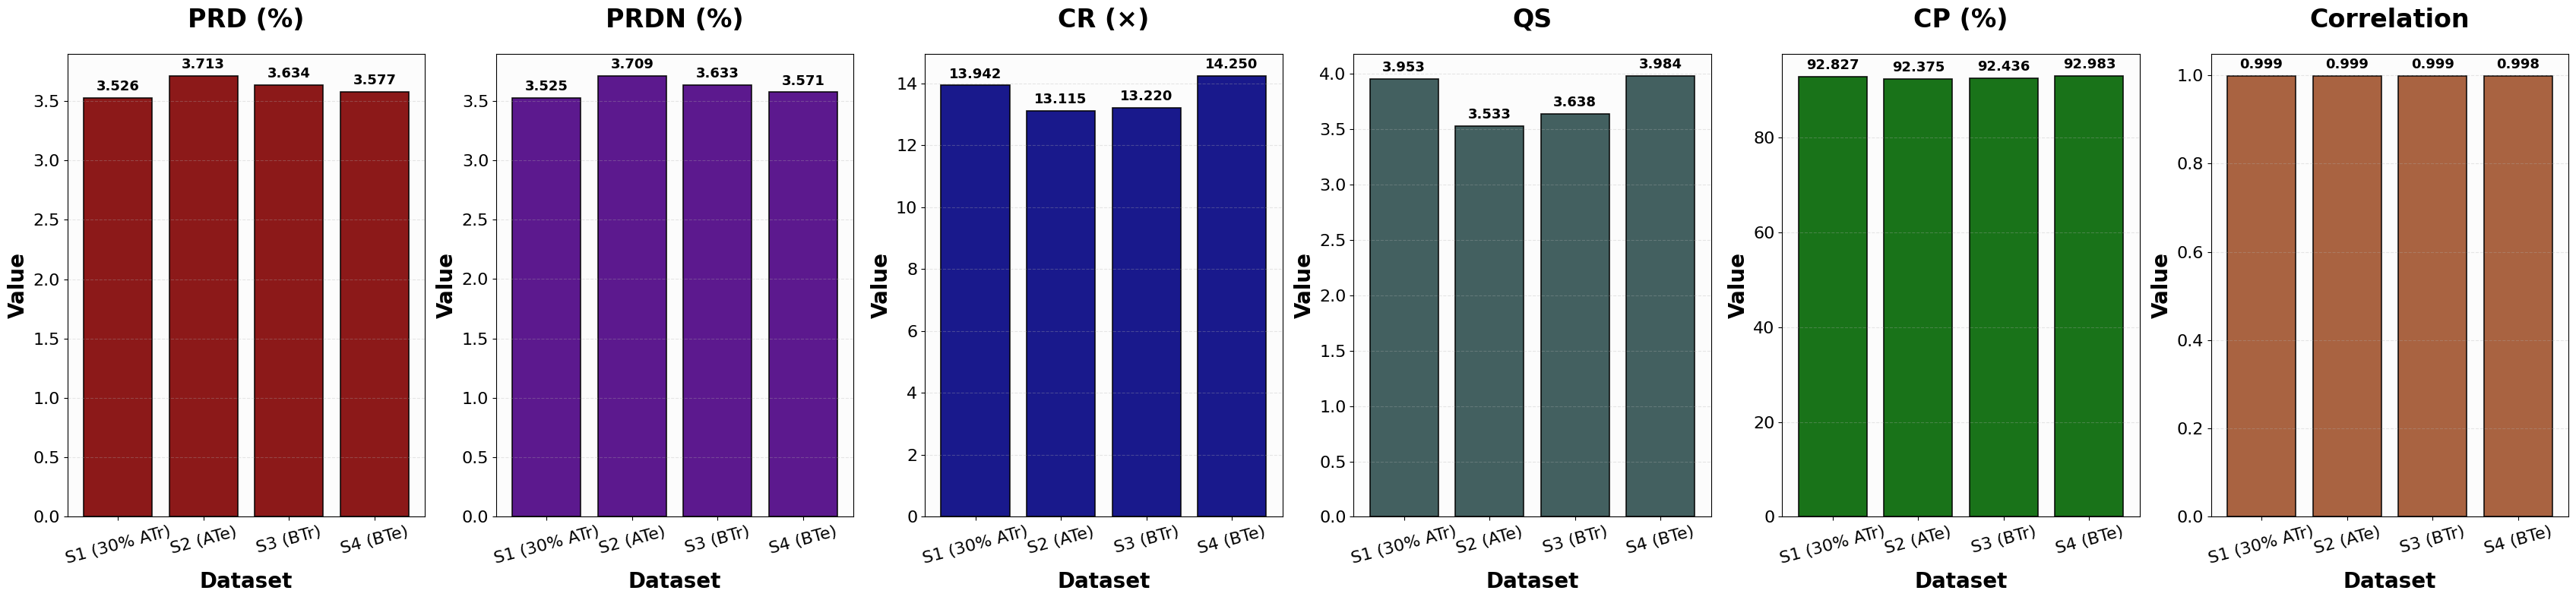

Refined BCI-III metrics report saved to bci3_metrics_single_row.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

if results:
    # --- CONFIGURATION: DARK COLORS & LARGE FONTS ---
    # Distinct dark colors for each metric
    METRIC_COLORS = ['#800000', '#4B0082', '#000080', '#2F4F4F', '#006400', '#A0522D']

    FS_HEADING = 24  # Subplot titles
    FS_LABEL   = 20  # X and Y axis labels
    FS_TICKS   = 16  # X and Y axis tick labels
    FS_TEXT    = 13  # Font for values on top of bars

    # Create figure: 1 row, 6 columns for side-by-side comparison
    fig, axes = plt.subplots(1, 6, figsize=(34, 8), sharey=False)

    labels = [r['Dataset'] for r in results]
    metrics_data = [
        ( [r['PRD'] for r in results],  'PRD (%)',      METRIC_COLORS[0]),
        ( [r['PRDN'] for r in results], 'PRDN (%)',     METRIC_COLORS[1]),
        ( [r['CR'] for r in results],   'CR (×)',       METRIC_COLORS[2]),
        ( [r['QS'] for r in results],   'QS',           METRIC_COLORS[3]),
        ( [r['CP'] for r in results],   'CP (%)',       METRIC_COLORS[4]),
        ( [r['Corr'][0] for r in results], 'Correlation',  METRIC_COLORS[5]) # FIX: Access the mean correlation
    ]

    for i, (ax, (vals, title, color)) in enumerate(zip(axes, metrics_data)):
        bars = ax.bar(labels, vals, color=color, edgecolor='black', linewidth=1.2, alpha=0.9)

        # 1. Styling Headings and Labels
        ax.set_title(title, fontsize=FS_HEADING, fontweight='bold', pad=25)
        ax.set_xlabel("Dataset", fontsize=FS_LABEL, fontweight='bold')
        ax.set_ylabel("Value", fontsize=FS_LABEL, fontweight='bold')

        # 2. Styling Ticks (Increased size and rotation for readability)
        ax.tick_params(axis='both', which='major', labelsize=FS_TICKS)
        plt.setp(ax.get_xticklabels(), rotation=15)


        # 4. Grid and Background styling
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_facecolor('#fcfcfc')

        # 5. Add Text labels on top of bars
        for bar, v in zip(bars, vals):
            height = bar.get_height()
            label_text = f'{v:.3f}'
            ax.text(bar.get_x() + bar.get_width()/2, height + (max(vals)*0.01),
                    label_text, ha='center', va='bottom',
                    fontsize=FS_TEXT, fontweight='bold', color='black')

    # Remove global figure title (suptitle) as requested
    plt.tight_layout()

    # Save the report
    plt.savefig('bci3_metrics_single_row.png', dpi=200, bbox_inches='tight')
    plt.show()

    print(f'Refined BCI-III metrics report saved to bci3_metrics_single_row.png')


In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_reconstruction_error(result, ch=0, n_blocks=4, fs=FS):
    """
    Saves a 3x1 Vertical Plot as a 600 DPI PDF for BCI III:
    - Zoomed in to show exactly from time = 0.00 to 0.40 seconds (like BCI2's 1_1.pdf)
    - Shared Y-axis for scale comparison.
    - No titles, larger ticks (16), and labels (18).
    - Custom legend labels and dark colors.
    """
    # 1. Data Processing
    orig  = result["originals"][:n_blocks, ch, :].reshape(-1).cpu().numpy()
    recon = result["reconstructed"][:n_blocks, ch, :].reshape(-1).cpu().numpy()
    error = orig - recon
    time  = np.arange(len(orig)) / fs

    # 2. Slice arrays to keep only the 0.00 to 0.40s segment
    time_mask = time <= 0.40
    time_sliced = time[time_mask]
    orig_sliced = orig[time_mask]
    recon_sliced = recon[time_mask]
    error_sliced = error[time_mask]

    # 3. Calculate Global Y-Limits for the zoomed portion
    y_min = min(orig_sliced.min(), recon_sliced.min(), error_sliced.min())
    y_max = max(orig_sliced.max(), recon_sliced.max(), error_sliced.max())
    padding = (y_max - y_min) * 0.1
    ylim = (y_min - padding, y_max + padding)

    # 4. Font Configuration
    FS_LABEL  = 18
    FS_TICKS  = 16
    FS_LEGEND = 14

    # 5. Create Figure (Proportioned to 14x10 to match BCI2/1_1.pdf)
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, sharey=True)

    # --- Subplot 1: Original Signal ---
    axes[0].plot(time_sliced, orig_sliced, color='#000080', linewidth=2.0, label='Original Signal')
    axes[0].set_ylabel("Amplitude (z)", fontsize=FS_LABEL)
    axes[0].tick_params(axis='both', labelsize=FS_TICKS)
    axes[0].legend(loc='upper left', fontsize=FS_LEGEND, frameon=True)
    axes[0].grid(True, linestyle='--', alpha=0.3)

    # --- Subplot 2: Reconstructed Signal ---
    axes[1].plot(time_sliced, recon_sliced, color='#800000', linewidth=2.0, label='Reconstructed Signal')
    axes[1].set_ylabel("Amplitude (z)", fontsize=FS_LABEL)
    axes[1].tick_params(axis='both', labelsize=FS_TICKS)
    axes[1].legend(loc='upper left', fontsize=FS_LEGEND, frameon=True)
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # --- Subplot 3: Reconstruction Error ---
    axes[2].plot(time_sliced, error_sliced, color='#006400', linewidth=1.5, label='Residual Error')
    axes[2].axhline(0, color='black', linewidth=1.2, linestyle='--')
    axes[2].set_xlabel("Time (s)", fontsize=FS_LABEL)
    axes[2].set_ylabel("Amplitude (z)", fontsize=FS_LABEL)
    axes[2].tick_params(axis='both', labelsize=FS_TICKS)
    axes[2].legend(loc='upper left', fontsize=FS_LEGEND, frameon=True)
    axes[2].grid(True, linestyle='--', alpha=0.3)

    # Set explicit X-axis ticks to match BCI2 (0.00, 0.05, 0.10, ..., 0.40)
    axes[2].set_xticks(np.arange(0.00, 0.41, 0.05))

    # 6. Apply Final Formatting (Y-limits across shared axes)
    for ax in axes:
        ax.set_ylim(ylim)

    plt.tight_layout()

    # 7. Save as PDF with 600 DPI
    plt.savefig("reconstruction_plot.pdf", format='pdf', dpi=600, bbox_inches='tight')
    plt.show()

# Execution
if 'results' in globals() and results:
    plot_reconstruction_error(results[0])
else:
    print("Results not available in notebook scope. Code defined successfully.")


In [13]:
save_path = '/content/drive/MyDrive/avdct_net_bci3_finetuned.pth'
torch.save({
    'edge_state_dict': edge.state_dict(),
    'fog_state_dict':  fog.state_dict(),
    'epoch':           NUM_EPOCHS,
    'tau': TAU, 'omega': OMEGA, 'quant_scale': QUANT_SCALE,
    'results': [{k: v for k, v in r.items() if k not in ('originals', 'reconstructed')}
                for r in results],
}, save_path)
print(f'Fine-tuned checkpoint saved to: {save_path}')


Fine-tuned checkpoint saved to: /content/drive/MyDrive/avdct_net_bci3_finetuned.pth


In [14]:
print('\n' + '='*100)
print('AVDCT-Net BCI3 Transfer Learning — Final Results Summary (cf. Paper Table II)')
print('='*100)
print(f'{"Dataset":<18} | {"PRD":>8} | {"PRDN":>8} | {"CR":>8} | {"QS":>8} | {"SNR":>9} | {"Corr":>7} | {"MSC":>7}')
print('-'*100)
for r in results:
    print(f'{r["Dataset"]:<18} | {r["PRD"]:>8.4f} | {r["PRDN"]:>8.4f} | '
          f'{r["CR"]:>8.2f} | {r["QS"]:>8.4f} | {r["SNR"]:>9.2f} | '
          f'{r["Corr"][0]:>7.4f} | {r["MSC"]:>7.4f}')
print('='*100)
avg_prd = sum(r['PRD'] for r in results) / len(results)
avg_cr  = sum(r['CR']  for r in results) / len(results)
avg_qs  = sum(r['QS']  for r in results) / len(results)
print(f'\nAverage PRD = {avg_prd:.4f}%  |  Average CR = {avg_cr:.2f}x  |  Average QS = {avg_qs:.4f}')



AVDCT-Net BCI3 Transfer Learning — Final Results Summary (cf. Paper Table II)
Dataset            |      PRD |     PRDN |       CR |       QS |       SNR |    Corr |     MSC
----------------------------------------------------------------------------------------------------
S1 (30% ATr)       |   3.5265 |   3.5250 |    13.94 |   3.9534 |     29.06 |  0.9987 |  0.9820
S2 (ATe)           |   3.7126 |   3.7094 |    13.12 |   3.5326 |     28.61 |  0.9991 |  0.9793
S3 (BTr)           |   3.6336 |   3.6325 |    13.22 |   3.6383 |     28.80 |  0.9991 |  0.9753
S4 (BTe)           |   3.5767 |   3.5706 |    14.25 |   3.9843 |     28.95 |  0.9985 |  0.9720

Average PRD = 3.6123%  |  Average CR = 13.63x  |  Average QS = 3.7771
